In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

import adaptive

from tai_localizer.lauralizer import amorphous_model_BHZ_2D as am
from tai_localizer.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ, zero_params
from tai_localizer.lauralizer.localizer import (
    spectral_localizer_AII2D,
    pfaff_sign,
    local_gap_localizer,
)
from tai_localizer.perulizer import proximity_lattice, proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl
import kwant as k

# local imports
from func_for_fig2 import param_obs_2b

adaptive.notebook_extension()

In [3]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [4]:
system_size = 10
A = 1.0
B = 1.0
delta = 2.0
alpha = 0.0
disorder_averages = 50
n_task = 5
bond_distance = 1.25 / system_size
kappa = 1
onsite_disorder = 0
hadamard_disorder = 0.15
beta = 3

sigma_bounds = (0.001, 0.5 / system_size)
delta_bounds = (-2, 4)
disorder_bounds = (0, 15)

In [5]:
# check it runs
x = param_obs_2b(
    system_size,
    sigma_bounds[-1],
    bond_distance,
    A,
    B,
    delta,
    onsite_disorder=onsite_disorder,
    hadamard_disorder=0.9,
    kappa=1,
    disorder_average=1,
    beta=beta,
)

u = lambda sig_delta: param_obs_2b(
    system_size,
    sig_delta[0],
    bond_distance,
    A,
    B,
    sig_delta[1],
    onsite_disorder=onsite_disorder,
    hadamard_disorder=hadamard_disorder,
    kappa=1,
    disorder_average=disorder_averages,
    beta=beta,
)
sigdelta = np.array([0.1, 3])
u(sigdelta)

/Users/perudornellas/python/packages/koala/src/koala/pointsets.py:196: RuntimeWarning: divide by zero encountered in divide
  h_int += (kappa) / (r**0.5)  # np.sum(r**2, axis = 0)


np.float64(0.4)

# 2.a

In [6]:
learner_dis = adaptive.Learner2D(
    lambda sig_delta: param_obs_2b(
        system_size,
        0,
        bond_distance,
        A,
        B,
        sig_delta[0],
        onsite_disorder=sig_delta[1],
        hadamard_disorder=hadamard_disorder,
        kappa=kappa,
        disorder_average=disorder_averages,
    ),
    bounds=[
        delta_bounds,
        disorder_bounds,
    ],
)


def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 1000  # continue until 1000 points

In [7]:
runner_dis = adaptive.Runner(
    learner_dis,
    goal=goal,
    ntasks=n_task,
)

runner_dis.live_info()

# 2.b

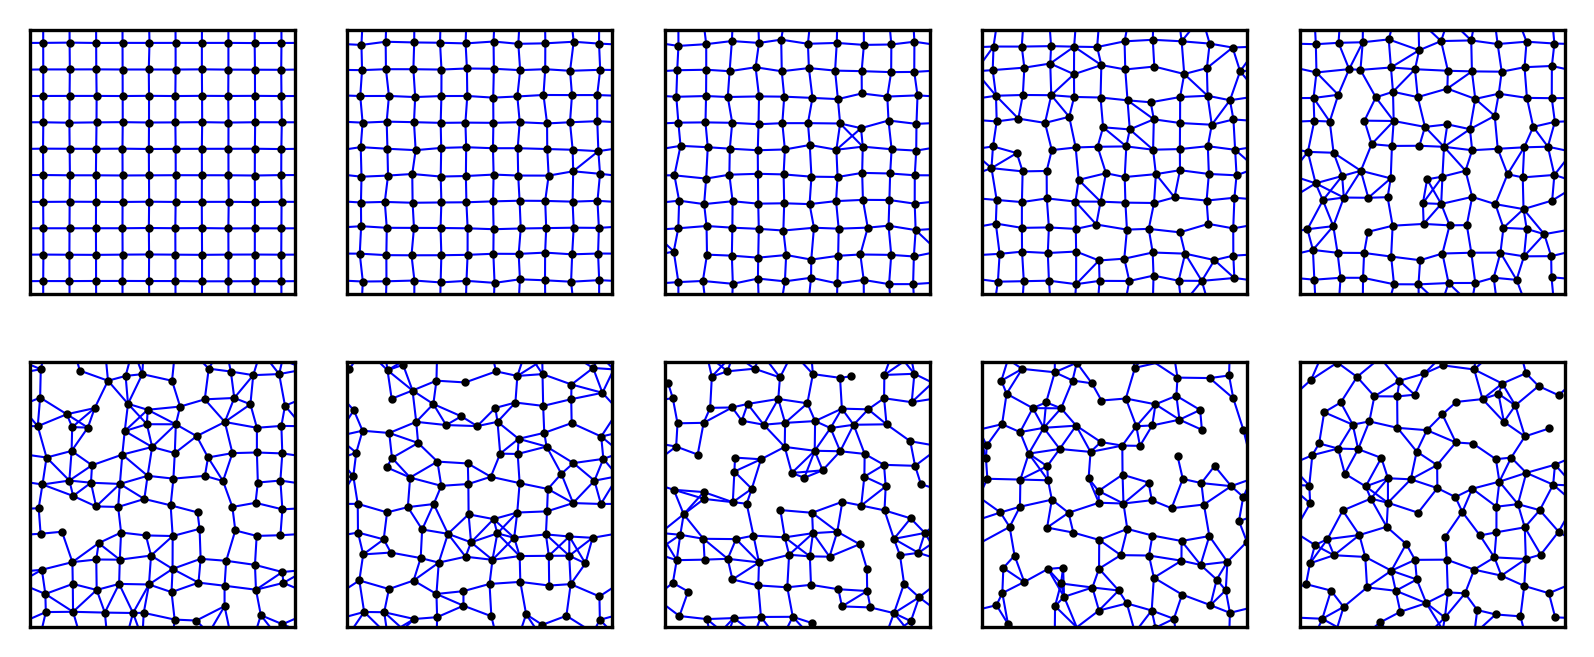

In [8]:
# lets add a check of the graphs that we want to generate
n_points = 10
initial_points = pointsets.grid(system_size, system_size)

fig, ax = plt.subplots(
    n_points // 5,
    5,
    figsize=(aps_figwidth, (n_points // 5) * aps_figwidth / 5),
    dpi=300,
)

sigmas = np.linspace(sigma_bounds[0], sigma_bounds[1], n_points)
for a, sigma in zip(ax.flatten(), sigmas):

    p = pointsets.move_all_points(initial_points, sigma, sigma, beta)

    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

    a.scatter(*p.T, s=1, color="black")
    lat = proximity_lattice(p, bond_distance)
    pl.plot_edges(lat, ax=a, color="blue", linewidth=0.5, zorder=-1)

In [ ]:
learner_sig = adaptive.Learner2D(
    lambda sig_delta: param_obs_2b(
        system_size,
        sig_delta[1],
        bond_distance,
        A,
        B,
        sig_delta[0],
        onsite_disorder=onsite_disorder,
        hadamard_disorder=hadamard_disorder,
        kappa=kappa,
        disorder_average=disorder_averages,
        bond_power=4,
    ),
    bounds=[
        delta_bounds,
        sigma_bounds,
    ],
)

In [10]:
runner_sig = adaptive.Runner(
    learner_sig,
    goal=goal,
    ntasks=n_task,
)

runner_sig.live_info()

In [11]:
runner_sig.task.print_stack()

Stack for <Task pending name='Task-57' coro=<AsyncRunner._run() running at /opt/homebrew/Caskroom/miniforge/base/envs/kwant/lib/python3.14/site-packages/adaptive/runner.py:796> wait_for=<Future pending cb=[Task.task_wakeup()]>> (most recent call last):


  File "/opt/homebrew/Caskroom/miniforge/base/envs/kwant/lib/python3.14/site-packages/adaptive/runner.py", line 796, in _run
    done, _ = await asyncio.wait(futures, return_when=first_completed)  # type: ignore[arg-type,type-var]


# Make the plot

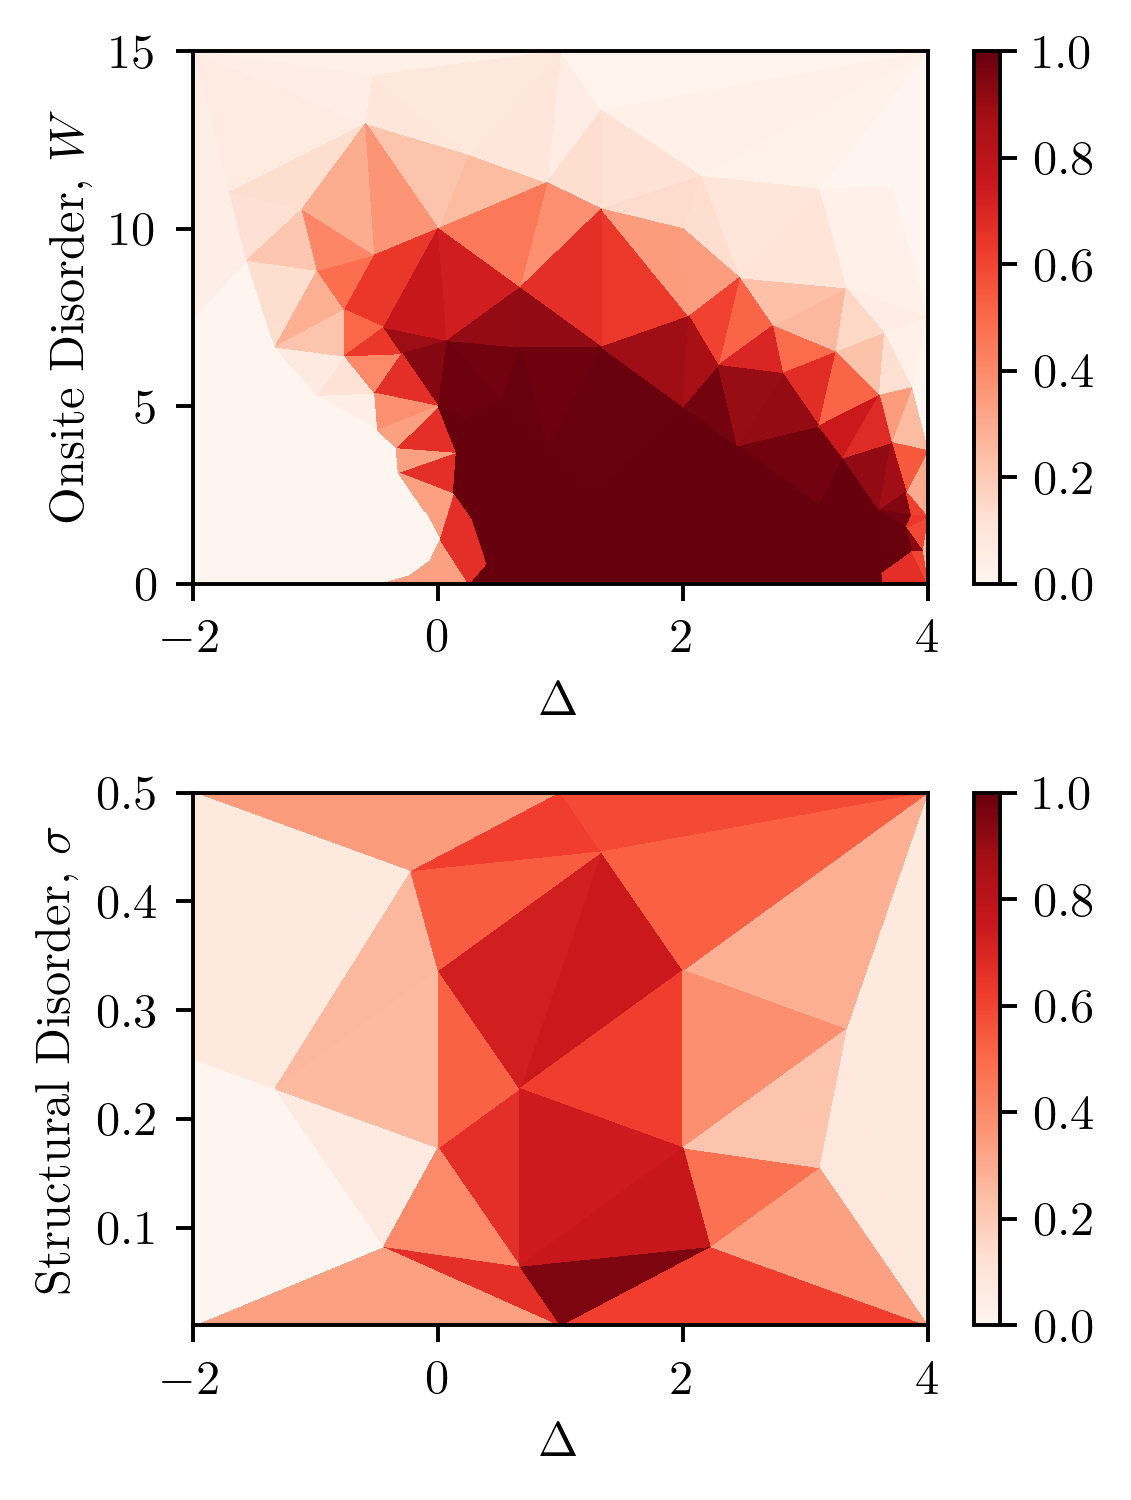

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(aps_halfwidth, 1.3 * aps_halfwidth), dpi=350)

######### 2a #########

specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)


p1 = ax[0].tripcolor(
    positions[:, 0],
    positions[:, 1],
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)


######### 2b #########
specs = np.array([learner_sig.data[k] for k in learner_sig.data.keys()])
positions = np.array([k for k in learner_sig.data.keys()])
specs = 0.5 * (1 - specs)

triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)

p2 = ax[1].tripcolor(
    positions[:, 0],
    positions[:, 1] * system_size,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)

ax[0].set_xlim(delta_bounds)
ax[1].set_xlim(delta_bounds)
ax[0].set_ylim(disorder_bounds)
ax[1].set_ylim(np.array(sigma_bounds) * system_size)

ax[0].set_xlabel(r"$\Delta$")
ax[1].set_xlabel(r"$\Delta$")
ax[0].set_ylabel(r"Onsite Disorder, $W$")
ax[1].set_ylabel(r"Structural Disorder, $\sigma$")

plt.colorbar(p1, ax=ax[0])
plt.colorbar(p2, ax=ax[1])

plt.tight_layout()

/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_2106/528109777.py:38: UserWarning: Adding colorbar to a different Figure <Figure size 1181.25x1535.62 with 4 Axes> than <Figure size 1181.25x1535.62 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(p2, ax=ax[1])


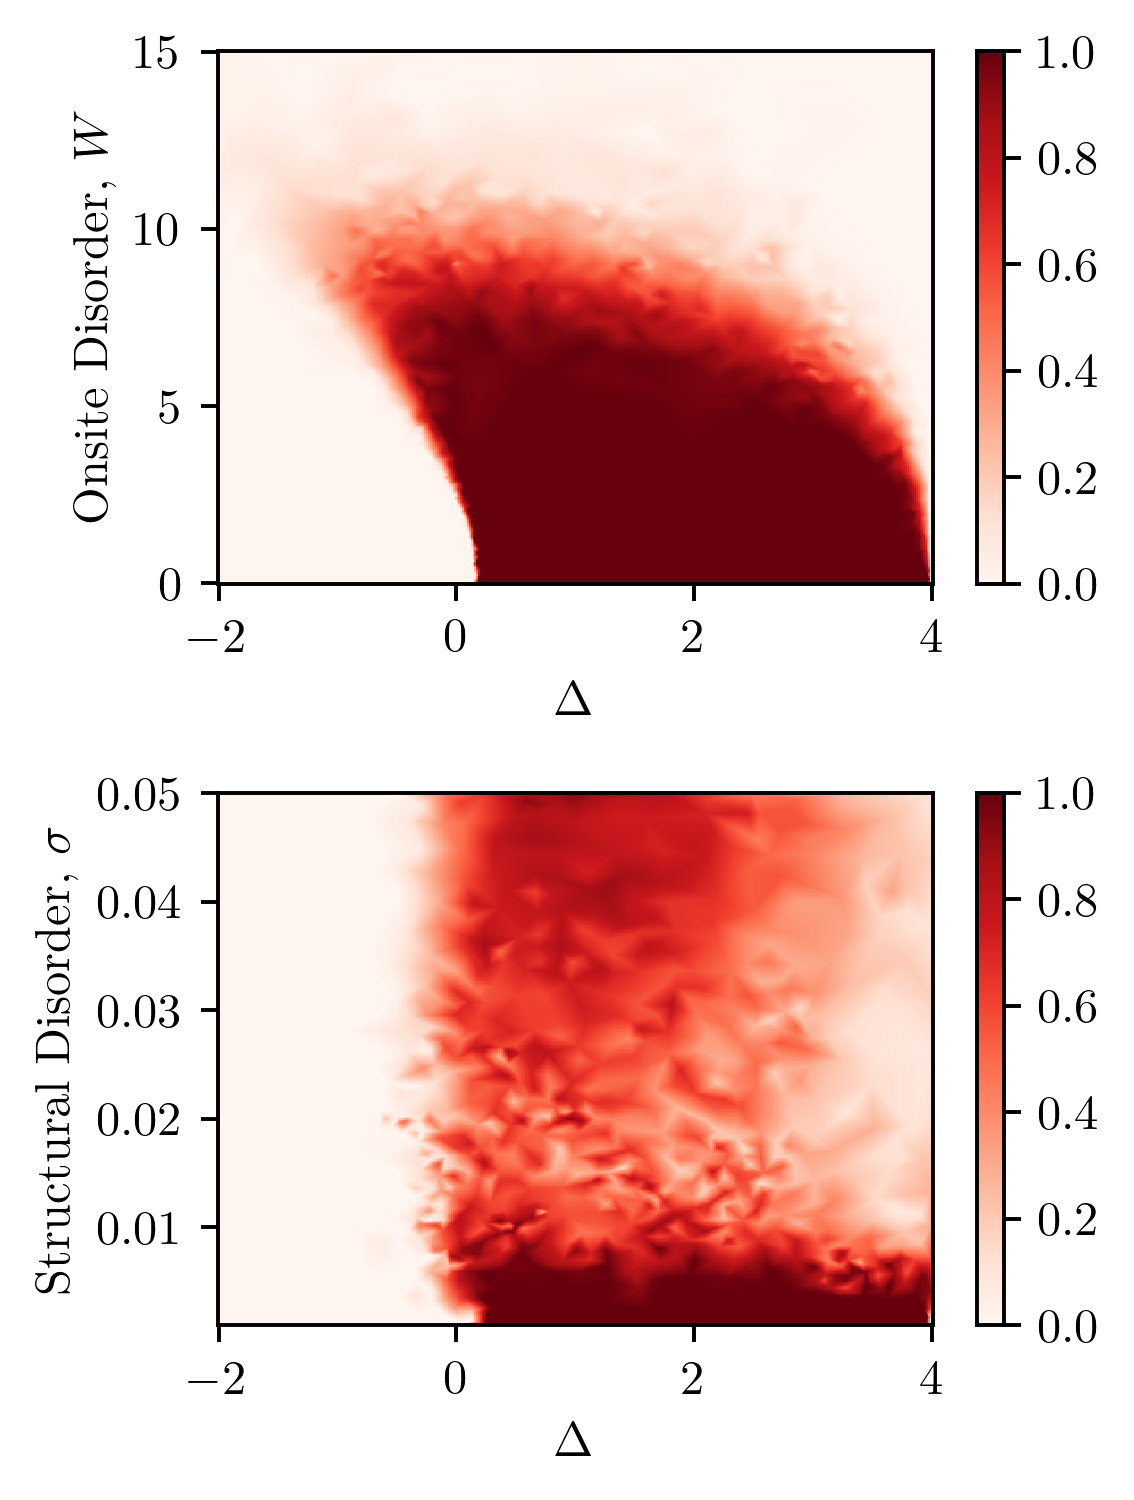

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(aps_halfwidth, 1.3 * aps_halfwidth), dpi=350)

######### 2a #########

x, y, i = learner_dis.interpolated_on_grid(400)

p1 = ax[0].pcolor(
    x.T,
    y.T,
    0.5 * (1 - i.T),
    cmap="Reds",
    # clim=(0, 1),
)


######### 2b #########
x, y, i = learner_sig.interpolated_on_grid(400)

p1 = ax[1].pcolor(
    x.T,
    y.T,
    0.5 * (1 - i.T),
    cmap="Reds",
    # clim=(0, 1),
)

# ax[0].set_xlim(delta_bounds)
# ax[1].set_xlim(delta_bounds)
# ax[0].set_ylim(disorder_bounds)
# ax[1].set_ylim(np.array(sigma_bounds) * system_size)

ax[0].set_xlabel(r"$\Delta$")
ax[1].set_xlabel(r"$\Delta$")
ax[0].set_ylabel(r"Onsite Disorder, $W$")
ax[1].set_ylabel(r"Structural Disorder, $\sigma$")

plt.colorbar(p1, ax=ax[0])
plt.colorbar(p2, ax=ax[1])

plt.tight_layout()